# Notebook 5: Probabilistic Clustering — Gaussian Mixture Models

**Block 3 — Unsupervised Learning**

Same probabilistic recipe, but now **unsupervised**: we observe $\mathbf{x}$ but not the cluster assignments $z$.

$$p(\mathbf{x}_i \mid \theta) = \sum_{k=1}^K \pi_k \;\mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

We will:
1. Cluster data with **$k$-means** (hard assignments).
2. Build a **Gaussian Mixture Model** in Pyro (soft assignments).
3. Train via MLE and visualize **cluster probabilities**.
4. Compare the two approaches.

## 0. Setup

In [1]:
!pip install pyro-ppl scikit-learn -q

You should consider upgrading via the '/Users/zp25hk/Library/CloudStorage/GoogleDrive-andresrmasegosa@gmail.com/My Drive/teaching/2026-Spring/2026-PhD-PML-Claude/.venv/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from matplotlib.patches import Ellipse

pyro.set_rng_seed(42)
torch.manual_seed(42)
np.random.seed(42)
pyro.clear_param_store()

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12
FIGURES_DIR = 'figures/'
import os
os.makedirs(FIGURES_DIR, exist_ok=True)


## 1. Synthetic clustering data

We generate data from 3 Gaussians with different shapes — this is a setting where
$k$-means struggles because clusters have different covariances.

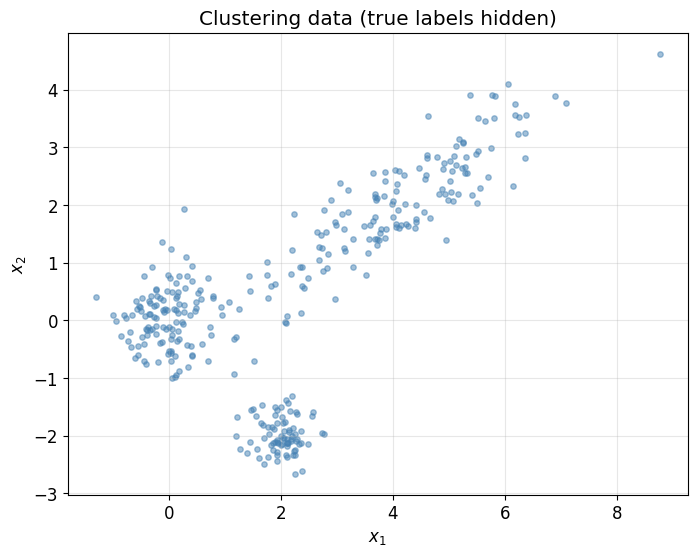

350 data points. The model does NOT see the true labels.


In [3]:
# True parameters
np.random.seed(42)

# Cluster 0: round cluster
n0 = 120
X0 = np.random.randn(n0, 2) * 0.5 + np.array([0, 0])

# Cluster 1: elongated cluster
n1 = 150
cov1 = np.array([[2.0, 1.2], [1.2, 1.0]])
X1 = np.random.multivariate_normal([4, 2], cov1, n1)

# Cluster 2: small tight cluster
n2 = 80
X2 = np.random.randn(n2, 2) * 0.3 + np.array([2, -2])

X_np = np.vstack([X0, X1, X2])
true_labels = np.concatenate([np.zeros(n0), np.ones(n1), 2*np.ones(n2)])
x_data = torch.tensor(X_np, dtype=torch.float32)
N = len(X_np)

plt.figure(figsize=(8, 6))
plt.scatter(X_np[:, 0], X_np[:, 1], alpha=0.5, s=15, color='steelblue')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.title('Clustering data (true labels hidden)')
plt.grid(True, alpha=0.3)
plt.savefig(f'{FIGURES_DIR}clustering_data.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'{N} data points. The model does NOT see the true labels.')

## 2. $k$-means: hard assignments

$k$-means assigns each point to the **nearest** cluster center.
It gives **hard** assignments: each point belongs to exactly one cluster.

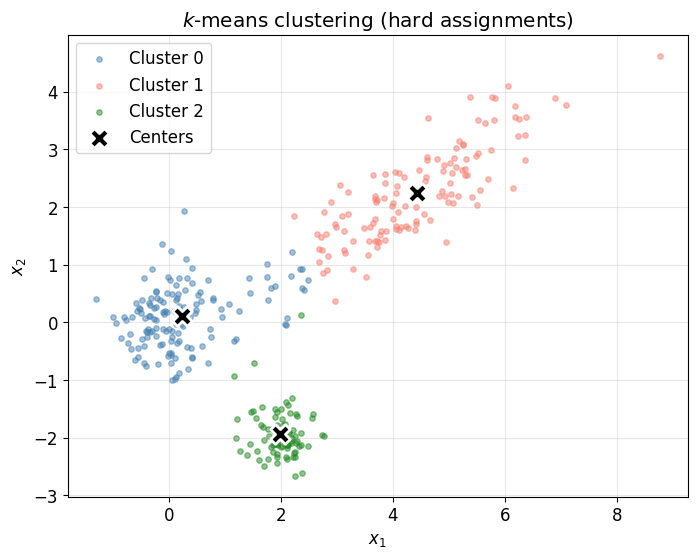

Each point belongs to exactly ONE cluster.
k-means cannot express uncertainty about assignments.
Also: k-means assumes spherical clusters — it cannot capture elongated shapes.


In [4]:
K = 3
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X_np)
km_centers = kmeans.cluster_centers_

colors = ['steelblue', 'salmon', 'forestgreen']

plt.figure(figsize=(8, 6))
for k in range(K):
    mask = km_labels == k
    plt.scatter(X_np[mask, 0], X_np[mask, 1], alpha=0.5, s=15,
                color=colors[k], label=f'Cluster {k}')
plt.scatter(km_centers[:, 0], km_centers[:, 1], s=200, c='black',
            marker='X', edgecolors='white', linewidths=2, zorder=5,
            label='Centers')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$')
plt.title('$k$-means clustering (hard assignments)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{FIGURES_DIR}kmeans_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

print('Each point belongs to exactly ONE cluster.')
print('k-means cannot express uncertainty about assignments.')
print('Also: k-means assumes spherical clusters — it cannot capture elongated shapes.')

## 3. Gaussian Mixture Model in Pyro

A GMM is the **probabilistic version** of $k$-means. For each data point:

1. **Choose a cluster:** $z_i \sim \mathrm{Categorical}(\boldsymbol{\pi})$
2. **Generate data:** $\mathbf{x}_i \mid z_i = k \sim \mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$

The latent variable $z_i$ is **not observed** — this is what makes it unsupervised.

### New Pyro concept: marginalizing out latent variables

Since $z_i$ is discrete, we can **sum it out** analytically:

$$p(\mathbf{x}_i \mid \theta) = \sum_{k=1}^K \pi_k \;\mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$$

Pyro provides `dist.MixtureSameFamily` to handle this automatically.

In [5]:
K = 3  # number of clusters

def gmm_model(x, K=3):
    """
    Gaussian Mixture Model.
    
    Parameters:
        pi    - mixture weights (how likely each cluster is)
        mu_k  - cluster centers (means)
        Sigma_k - cluster shapes (covariances, parameterized via Cholesky)
    """
    N, D = x.shape
    
    # Mixture weights: K probabilities that sum to 1
    # We parameterize in log-space and softmax for stability
    mix_logits = pyro.param('mix_logits', torch.zeros(K))
    
    # Cluster means: K centers in D dimensions
    locs = pyro.param('locs', torch.randn(K, D))
    
    # Cluster covariances via Cholesky factors (lower triangular)
    # This ensures covariance matrices are positive definite
    scale_tril = pyro.param(
        'scale_tril',
        torch.eye(D).unsqueeze(0).repeat(K, 1, 1),  # K copies of identity
        constraint=dist.constraints.lower_cholesky
    )
    
    # Build the mixture distribution
    mix = dist.Categorical(logits=mix_logits)
    components = dist.MultivariateNormal(loc=locs, scale_tril=scale_tril)
    gmm = dist.MixtureSameFamily(mix, components)
    
    # Observe data
    with pyro.plate('data', N):
        pyro.sample('obs', gmm, obs=x)

def empty_guide(x, K=3):
    pass

print('GMM model defined.')
print(f'  - {K} clusters with learnable means and covariances')
print(f'  - Mixture weights learned via softmax of logits')
print(f'  - Same Pyro structure: pyro.param + pyro.plate + pyro.sample')

GMM model defined.
  - 3 clusters with learnable means and covariances
  - Mixture weights learned via softmax of logits
  - Same Pyro structure: pyro.param + pyro.plate + pyro.sample


## 4. Training

Same SVI setup as all previous notebooks. The loss is the negative log-likelihood of the mixture.

Step  500 | Loss (NLL): 932.95
Step 1000 | Loss (NLL): 932.95
Step 1500 | Loss (NLL): 932.95


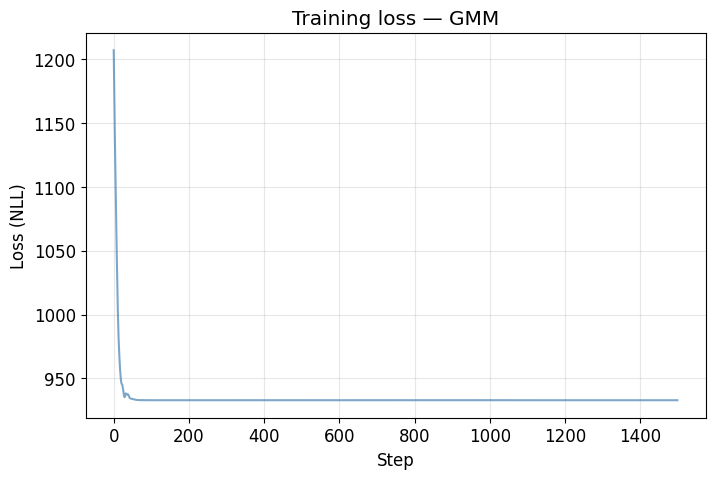

In [6]:
pyro.clear_param_store()

# Initialize means near the data (helps convergence)
# In practice, k-means initialization is common
init_locs = torch.tensor(km_centers, dtype=torch.float32)
pyro.param('locs', init_locs)

svi = SVI(gmm_model, empty_guide, Adam({'lr': 0.05}), loss=Trace_ELBO())

losses = []
for step in range(1500):
    loss = svi.step(x_data, K)
    losses.append(loss)
    if (step + 1) % 500 == 0:
        print(f'Step {step+1:4d} | Loss (NLL): {loss:.2f}')

plt.plot(losses, color='steelblue', alpha=0.7)
plt.xlabel('Step'); plt.ylabel('Loss (NLL)')
plt.title('Training loss — GMM'); plt.grid(True, alpha=0.3)
plt.show()

## 5. Learned parameters

In [7]:
# Extract learned parameters
mix_logits = pyro.param('mix_logits').detach()
mix_weights = torch.softmax(mix_logits, dim=0)
locs = pyro.param('locs').detach()
scale_tril = pyro.param('scale_tril').detach()

print('Learned mixture weights (pi):')
for k in range(K):
    print(f'  Cluster {k}: pi={mix_weights[k]:.3f}')

print(f'\nTrue proportions: {n0/N:.3f}, {n1/N:.3f}, {n2/N:.3f}')

print('\nLearned cluster means:')
for k in range(K):
    print(f'  Cluster {k}: mu={locs[k].numpy()}')

print('\nLearned covariance matrices (Sigma = L @ L^T):')
for k in range(K):
    cov_k = scale_tril[k] @ scale_tril[k].T
    print(f'  Cluster {k}:\n{cov_k.numpy().round(3)}')

Learned mixture weights (pi):
  Cluster 0: pi=0.341
  Cluster 1: pi=0.430
  Cluster 2: pi=0.229

True proportions: 0.343, 0.429, 0.229

Learned cluster means:
  Cluster 0: mu=[-0.05223267  0.05340156]
  Cluster 1: mu=[3.9689085 1.9226776]
  Cluster 2: mu=[ 1.9981141 -1.989142 ]

Learned covariance matrices (Sigma = L @ L^T):
  Cluster 0:
[[0.195 0.02 ]
 [0.02  0.264]]
  Cluster 1:
[[2.182 1.393]
 [1.393 1.115]]
  Cluster 2:
[[ 0.099 -0.003]
 [-0.003  0.089]]


## 6. Soft assignments — the key advantage

Instead of hard assignments, the GMM gives a **probability distribution** over clusters for each point.

We compute $p(z_i = k \mid \mathbf{x}_i)$ using Bayes' rule:

$$p(z_i = k \mid \mathbf{x}_i) = \frac{\pi_k \;\mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)}{\sum_{j=1}^K \pi_j \;\mathcal{N}(\mathbf{x}_i \mid \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}$$

Points near cluster boundaries have **uncertain assignments** — the model knows it's not sure.

In [8]:
def compute_responsibilities(x, mix_weights, locs, scale_tril):
    """Compute p(z_i = k | x_i) for each point and cluster."""
    K = len(mix_weights)
    log_resp = torch.zeros(len(x), K)
    for k in range(K):
        mvn = dist.MultivariateNormal(loc=locs[k], scale_tril=scale_tril[k])
        log_resp[:, k] = torch.log(mix_weights[k]) + mvn.log_prob(x)
    # Normalize (softmax over clusters)
    log_resp -= torch.logsumexp(log_resp, dim=1, keepdim=True)
    return torch.exp(log_resp)

responsibilities = compute_responsibilities(x_data, mix_weights, locs, scale_tril)
hard_assignments = responsibilities.argmax(dim=1).numpy()
max_probs = responsibilities.max(dim=1).values.numpy()

print('Example soft assignments (first 5 points):')
print(f'{"Point":>6s}  {"p(z=0)":>8s}  {"p(z=1)":>8s}  {"p(z=2)":>8s}  {"Assigned":>8s}')
for i in range(5):
    r = responsibilities[i]
    print(f'{i:6d}  {r[0]:8.4f}  {r[1]:8.4f}  {r[2]:8.4f}  {hard_assignments[i]:8d}')

# Find uncertain points
uncertain_mask = max_probs < 0.8
print(f'\n{uncertain_mask.sum()} points have assignment probability < 0.8')
print('These are the points where the model is genuinely uncertain.')

Example soft assignments (first 5 points):
 Point    p(z=0)    p(z=1)    p(z=2)  Assigned
     0    0.9840    0.0160    0.0000         0
     1    0.9968    0.0032    0.0000         0
     2    0.9954    0.0046    0.0000         0
     3    0.8609    0.1391    0.0000         0
     4    0.9992    0.0008    0.0000         0

7 points have assignment probability < 0.8
These are the points where the model is genuinely uncertain.


## 7. Visualization: GMM with uncertainty

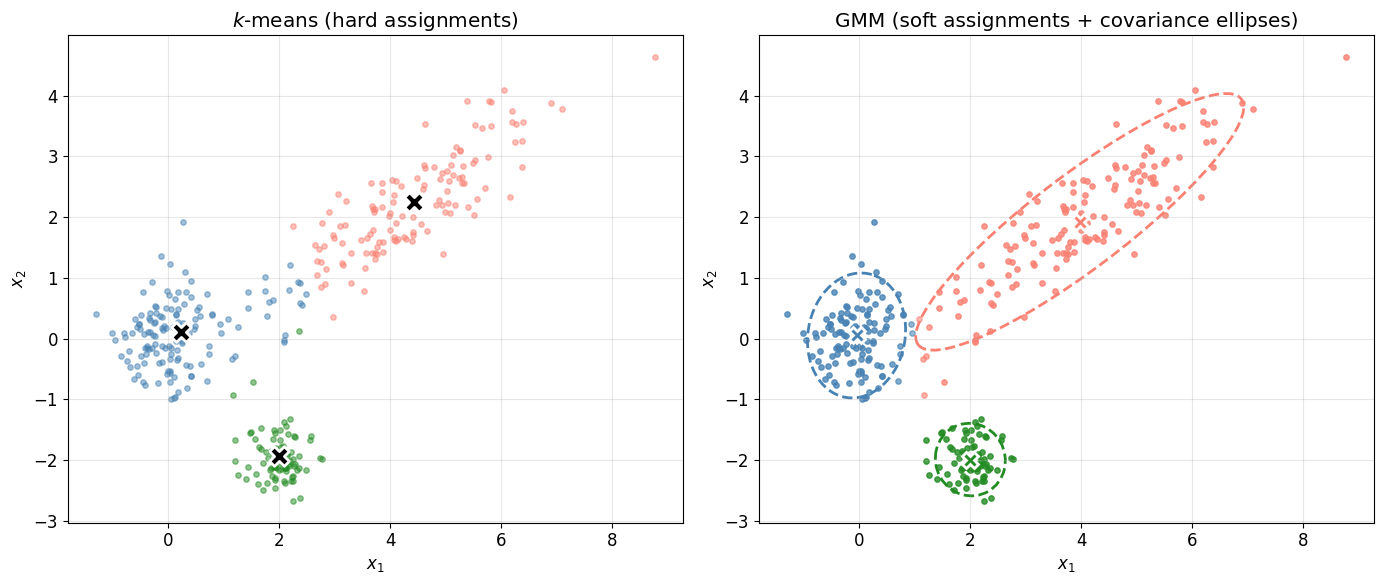

Left: k-means — all points fully opaque (no uncertainty).
Right: GMM — faded points = uncertain assignments, ellipses = learned cluster shapes.


In [9]:
def draw_ellipse(ax, mean, cov, n_std=2.0, color='black', **kwargs):
    """Draw an ellipse representing a 2D Gaussian."""
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(vals)
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  edgecolor=color, facecolor='none', linewidth=2, **kwargs)
    ax.add_patch(ell)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: k-means
ax = axes[0]
for k in range(K):
    mask = km_labels == k
    ax.scatter(X_np[mask, 0], X_np[mask, 1], alpha=0.5, s=15, color=colors[k])
ax.scatter(km_centers[:, 0], km_centers[:, 1], s=200, c='black',
           marker='X', edgecolors='white', linewidths=2, zorder=5)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('$k$-means (hard assignments)')
ax.grid(True, alpha=0.3)

# Right: GMM with soft assignments
ax = axes[1]
# Color each point by its most likely cluster, transparency = confidence
for i in range(N):
    k = hard_assignments[i]
    alpha = 0.2 + 0.6 * max_probs[i]  # more confident = more opaque
    ax.scatter(X_np[i, 0], X_np[i, 1], s=15, color=colors[k], alpha=alpha)

# Draw covariance ellipses
for k in range(K):
    cov_k = (scale_tril[k] @ scale_tril[k].T).numpy()
    draw_ellipse(ax, locs[k].numpy(), cov_k, n_std=2.0, color=colors[k],
                 linestyle='--')
    ax.plot(locs[k, 0], locs[k, 1], marker='X', markersize=12,
            color=colors[k], markeredgecolor='white', markeredgewidth=2, zorder=5)

ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('GMM (soft assignments + covariance ellipses)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}kmeans_vs_gmm.png', dpi=150, bbox_inches='tight')
plt.show()

print('Left: k-means — all points fully opaque (no uncertainty).')
print('Right: GMM — faded points = uncertain assignments, ellipses = learned cluster shapes.')

## 8. GMM soft assignments heatmap

We can also visualize $p(z = k \mid \mathbf{x})$ across the input space — like the probability contours in Block 2.

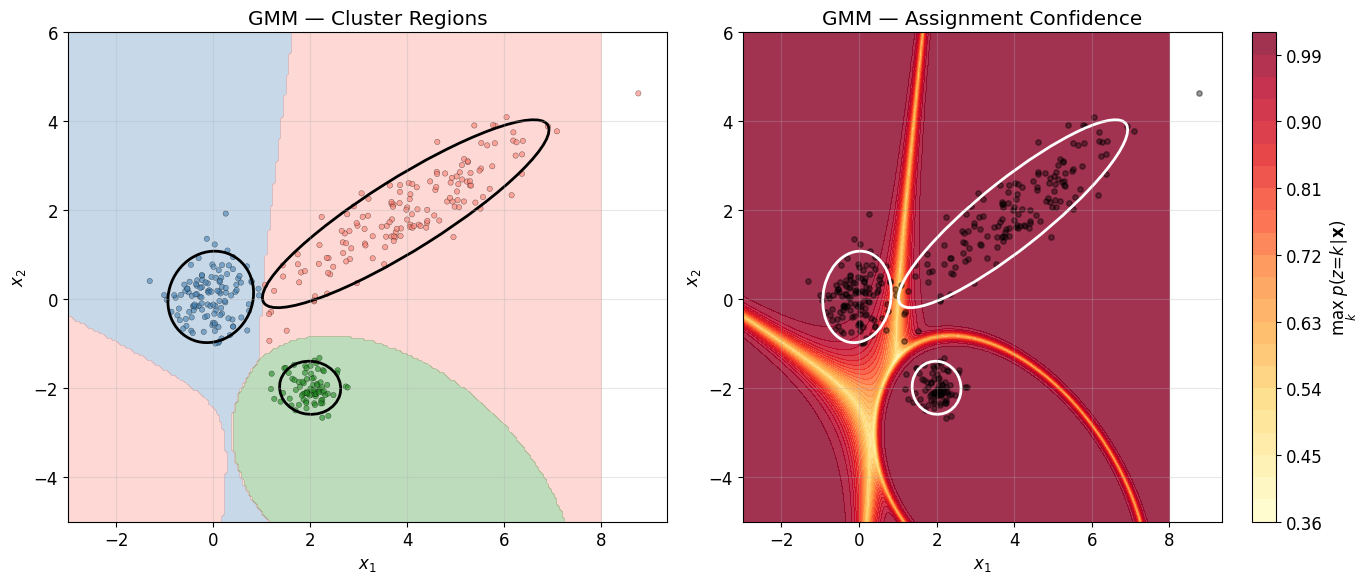

Left: colored regions show which cluster "wins" at each location.
Right: dark red = confident, yellow = uncertain (near cluster boundaries).


In [10]:
# Create grid
xx, yy = np.meshgrid(np.linspace(-3, 8, 200), np.linspace(-5, 6, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

# Compute responsibilities on grid
grid_resp = compute_responsibilities(grid, mix_weights, locs, scale_tril)
grid_hard = grid_resp.argmax(dim=1).numpy().reshape(xx.shape)
grid_max_prob = grid_resp.max(dim=1).values.numpy().reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: cluster assignment regions
ax = axes[0]
from matplotlib.colors import ListedColormap
cmap_clusters = ListedColormap(['#4682B4', '#FA8072', '#228B22'])
ax.contourf(xx, yy, grid_hard, levels=[-0.5, 0.5, 1.5, 2.5],
            cmap=cmap_clusters, alpha=0.3)
ax.scatter(X_np[:, 0], X_np[:, 1], c=[colors[k] for k in hard_assignments],
           s=15, alpha=0.6, edgecolors='k', linewidths=0.3)
for k in range(K):
    cov_k = (scale_tril[k] @ scale_tril[k].T).numpy()
    draw_ellipse(ax, locs[k].numpy(), cov_k, n_std=2.0, color='black')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('GMM — Cluster Regions')
ax.grid(True, alpha=0.3)

# Right: assignment confidence
ax = axes[1]
contour = ax.contourf(xx, yy, grid_max_prob, levels=20, cmap='YlOrRd', alpha=0.8)
plt.colorbar(contour, ax=ax, label='$\\max_k \; p(z=k \mid \mathbf{x})$')
ax.scatter(X_np[:, 0], X_np[:, 1], s=15, alpha=0.4, color='black')
for k in range(K):
    cov_k = (scale_tril[k] @ scale_tril[k].T).numpy()
    draw_ellipse(ax, locs[k].numpy(), cov_k, n_std=2.0, color='white')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('GMM — Assignment Confidence')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}gmm_soft_assignments.png', dpi=150, bbox_inches='tight')
plt.show()

print('Left: colored regions show which cluster "wins" at each location.')
print('Right: dark red = confident, yellow = uncertain (near cluster boundaries).')

## 8b. Clustering accuracy vs. assignment confidence

Since we generated the data ourselves, we have **true labels** and can measure how well the GMM clusters match reality.

**Key insight:** Points with uncertain soft assignments (low $\max_k p(z=k \mid \mathbf{x})$) are the ones most likely to be **misclassified**. If we remove them from the evaluation, the clustering accuracy should increase.

This demonstrates a practical benefit of soft assignments: they let us **identify which predictions are unreliable** and filter them out for downstream tasks.

In [11]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import accuracy_score

def align_labels(true_labels, pred_labels, K):
    """
    Cluster labels are arbitrary (cluster '0' in GMM might correspond to
    true label '2'). We find the best mapping using the Hungarian algorithm.
    """
    cost = np.zeros((K, K), dtype=int)
    for k_pred in range(K):
        for k_true in range(K):
            cost[k_pred, k_true] = -np.sum((pred_labels == k_pred) & (true_labels == k_true))
    row_ind, col_ind = linear_sum_assignment(cost)
    mapping = {row_ind[i]: col_ind[i] for i in range(K)}
    return np.array([mapping[p] for p in pred_labels])

# Align GMM cluster labels to true labels
K = 3
aligned_gmm = align_labels(true_labels.astype(int), hard_assignments, K)

# --- Accuracy at different confidence thresholds ---
thresholds = np.arange(0.35, 1.001, 0.025)
accuracies = []
fractions_retained = []

for t in thresholds:
    keep = max_probs >= t
    if keep.sum() == 0:
        accuracies.append(np.nan)
        fractions_retained.append(0.0)
        continue
    acc = accuracy_score(true_labels[keep].astype(int), aligned_gmm[keep])
    accuracies.append(acc)
    fractions_retained.append(keep.sum() / N)

# Overall accuracy (no filtering)
overall_acc = accuracy_score(true_labels.astype(int), aligned_gmm)
print(f'Overall GMM clustering accuracy (all points): {overall_acc:.3f}')
print(f'Number of misclassified points: {int((1 - overall_acc) * N)} / {N}')

# Show which points are misclassified
misclassified = aligned_gmm != true_labels.astype(int)
mis_confidence = max_probs[misclassified]
print(f'\nConfidence of misclassified points:')
print(f'  Mean: {mis_confidence.mean():.3f}')
print(f'  Max:  {mis_confidence.max():.3f}')
print(f'  All below 0.90: {(mis_confidence < 0.90).all()}')


Overall GMM clustering accuracy (all points): 0.986
Number of misclassified points: 4 / 350

Confidence of misclassified points:
  Mean: 0.819
  Max:  0.994
  All below 0.90: False


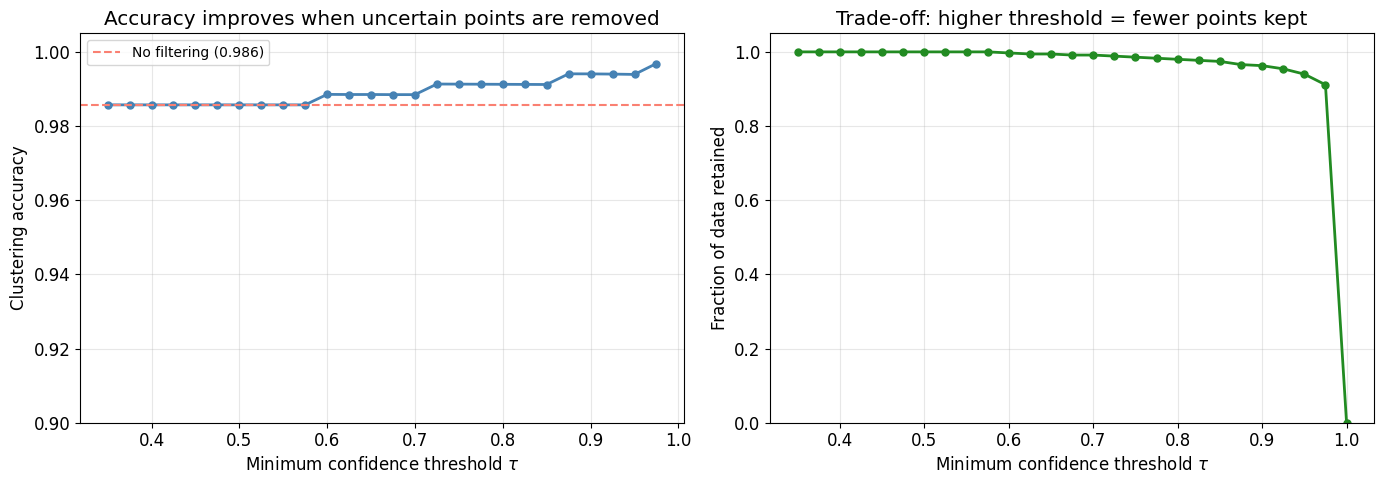

As we raise the confidence threshold, we discard uncertain points.
The remaining points are classified with increasing accuracy.
This is a practical advantage of soft assignments over k-means.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Accuracy vs. confidence threshold
ax = axes[0]
ax.plot(thresholds, accuracies, 'o-', color='steelblue', linewidth=2, markersize=5)
ax.axhline(overall_acc, color='salmon', linestyle='--', linewidth=1.5,
           label=f'No filtering ({overall_acc:.3f})')
ax.set_xlabel('Minimum confidence threshold $\\tau$', fontsize=12)
ax.set_ylabel('Clustering accuracy', fontsize=12)
ax.set_title('Accuracy improves when uncertain points are removed')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0.9, 1.005)

# Right: Fraction of data retained vs. threshold
ax2 = axes[1]
ax2.plot(thresholds, fractions_retained, 'o-', color='forestgreen', linewidth=2, markersize=5)
ax2.set_xlabel('Minimum confidence threshold $\\tau$', fontsize=12)
ax2.set_ylabel('Fraction of data retained', fontsize=12)
ax2.set_title('Trade-off: higher threshold = fewer points kept')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}accuracy_vs_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

print('As we raise the confidence threshold, we discard uncertain points.')
print('The remaining points are classified with increasing accuracy.')
print('This is a practical advantage of soft assignments over k-means.')


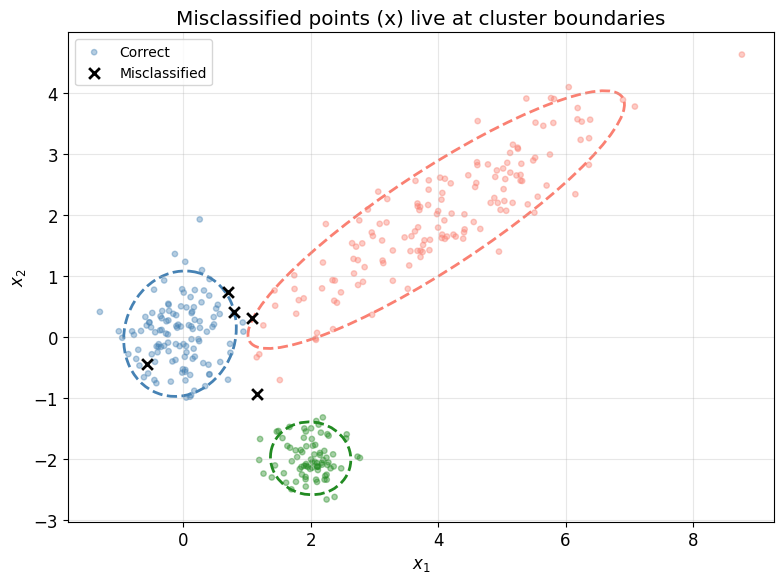

All misclassified points are near cluster boundaries — exactly where
the model reports low confidence. The soft assignments correctly flag
these uncertain predictions.


In [13]:
# Visualize which points are misclassified — they sit at cluster boundaries
fig, ax = plt.subplots(figsize=(8, 6))

correct = ~misclassified
ax.scatter(X_np[correct, 0], X_np[correct, 1], c=[colors[k] for k in aligned_gmm[correct]],
           s=15, alpha=0.4, label='Correct')
ax.scatter(X_np[misclassified, 0], X_np[misclassified, 1], c='black',
           s=60, marker='x', linewidths=2, zorder=5, label='Misclassified')

# Draw covariance ellipses
for k in range(K):
    cov_k = (scale_tril[k] @ scale_tril[k].T).numpy()
    draw_ellipse(ax, locs[k].numpy(), cov_k, n_std=2.0, color=colors[k], linestyle='--')

ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title('Misclassified points (x) live at cluster boundaries')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}misclassified_points.png', dpi=150, bbox_inches='tight')
plt.show()

print('All misclassified points are near cluster boundaries — exactly where')
print('the model reports low confidence. The soft assignments correctly flag')
print('these uncertain predictions.')


## Exercise: From clusters to labels — who names the clusters?

In the analysis above we used `align_labels` to match GMM clusters to true labels. But this was
possible **only because we generated the data ourselves**. In a real application, clusters have no
inherent meaning — they are just "cluster 0", "cluster 1", etc.

Imagine the following scenario: you have clustered a dataset of patients using a GMM, and a
doctor can manually label a **small subset** of patients (say, $n_{\text{labeled}} = 10$) with
the true disease subtype. You use those labeled points to assign a class name to each cluster.

---

### Part 1 — Labeling clusters via a small labeled set

1. Write a function `label_clusters(X_labeled, y_labeled, responsibilities_labeled, K)` that:
   - Assigns each labeled point to its most likely cluster (hard assignment).
   - For each cluster $k$, determines the class name by **majority vote** among the labeled
     points assigned to it.
   - Returns a mapping `{cluster_id: class_name}`.

2. Select 10 labeled points **at random** from our dataset (using `true_labels` as the doctor's
   annotations). Use your function to build the cluster→class mapping, then predict classes
   for **all** remaining points. Measure accuracy.

3. Repeat step 2 fifty times (different random draws of 10 points) and report the **mean and
   standard deviation** of the accuracy. Is the labeling stable or does it vary a lot?

### Part 2 — Smart selection: which points should the doctor label?

4. Instead of choosing the 10 labeled points at random, select the 10 points with the
   **highest assignment confidence** ($\max_k p(z=k \mid \mathbf{x})$). Repeat the labeling
   procedure and measure accuracy. Compare with the random baseline from step 3.

5. Why does choosing high-confidence points produce a more stable and accurate labeling?
   *(Hint: think about what happens if the doctor labels a point that sits right on a cluster
   boundary.)*

### Part 3 — Selective prediction (abstention)

6. Implement a function `selective_predict(responsibilities, threshold)` that:
   - Returns the hard cluster assignment for points where $\max_k p(z=k \mid \mathbf{x}) \geq \tau$.
   - Returns $-1$ ("I don't know") for the rest.

7. Sweep $\tau$ from 0.5 to 0.99 and compute:
   - **Accuracy** on non-abstained points.
   - **Coverage** (fraction of points that receive a prediction).
   Plot accuracy vs. coverage. Add the $k$-means accuracy as a horizontal line.

8. **Reflection:** In a hospital deployment, the doctor reviews the "abstained" cases manually.
   There is a cost per manual review. How would you choose $\tau$ in practice? What happens
   if a cluster does not correspond to any known disease — is that a failure of the model,
   or a discovery?


In [14]:
# ============================================================
# YOUR CODE HERE
# ============================================================

# Part 1: label_clusters function
def label_clusters(y_labeled, responsibilities_labeled, K):
    """
    Assign a class name to each cluster using a small labeled set.
    
    Args:
        y_labeled: true labels for the labeled subset (array of ints)
        responsibilities_labeled: p(z=k|x) for the labeled subset (N_labeled x K)
        K: number of clusters
    
    Returns:
        mapping: dict {cluster_id: class_name}
    """
    # TODO: implement majority vote labeling
    pass


# Part 1.2-3: Random selection experiment
# TODO: select 10 random labeled points, build mapping, measure accuracy
# TODO: repeat 50 times and report mean ± std


# Part 2: Smart selection
# TODO: select 10 highest-confidence points, compare accuracy


# Part 3: Selective prediction
def selective_predict(responsibilities, threshold):
    """
    Predict cluster assignment, or -1 if confidence < threshold.
    
    Args:
        responsibilities: p(z=k|x) for all points (N x K)
        threshold: minimum confidence to make a prediction
    
    Returns:
        predictions: array of ints (-1 = abstain)
    """
    # TODO: implement selective prediction
    pass

# TODO: sweep thresholds, plot accuracy vs. coverage


## 9. Summary

| | $k$-means | GMM |
|:--|:--|:--|
| **Assignments** | Hard (0 or 1) | Soft (probabilities) |
| **Cluster shape** | Spherical | Any (via $\Sigma_k$) |
| **Uncertainty** | None | Per-point uncertainty |
| **Model selection** | Heuristic | Likelihood-based (BIC) |
| **Generative** | No | Yes — can sample new data |
| **Pyro code** | — | Same primitives as Blocks 1 & 2 |

**Key takeaways:**
- Same Pyro primitives: `pyro.param`, `pyro.sample`, `pyro.plate`, `SVI`.
- New ingredient: **latent variables** ($z_i$) — marginalized out via `MixtureSameFamily`.
- The probabilistic model gives us **soft assignments** and **principled model selection**.
- Same recipe as Blocks 1 & 2: define model → infer → predict with uncertainty.

**What's next (Day 2):** Instead of point estimates (MLE), we put **distributions over parameters** — Bayesian inference captures *epistemic uncertainty*.